This is a foundational roadblock in my understanding of programming that I got stuck on while trying to go through the Quant ECOn coursework. As such, object oriented progamming will be treated as a priority in understanding going forward as I have previously not made the effort to properly understand this. The video I will be using is from Mr. P Solver and after this I will write out some class based programming for economics. It is important that I write this stuff out now in order to actually understand and will write this underneath all of the examples provided by the youtube video

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Think of class as thinking about a particular object and that we define qualities around the object that we defined and we can define and scale the attributes to deal with in the class. The __init__ serve as a way that we initialize something and its called when we first create the class. Now after we define our first instance of our class, we can then define variables and assign them to specific values we defined (apart from the __self__ in our __init__) and we can use this in order to have different instances of the same class. __Move__ represents a kind of modifier of the class which represents how the class may change over a period of time and represents operations within the assigned parameters in the class. Notice for our particle that the new position __x = velocity in direction x (vx) * t__. 

In [3]:
class Particle():
    def __init__(self, x ,y, z, vx, vy, vz, m): 
        self.x = x
        self.y = y
        self.z = z
        self.vx = vx
        self.vy = vy
        self.vz = vz
        self.m = m
    def move(self,t):
        self.x += self.vx * t
        self.y += self.vy * t
        self.z += self.vz * t
    def get_distance_from_origin(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
        
        
        

In [4]:
p1 = Particle(3,0,1,1,0,0,3)

Here notice when we call for x, itll show the exact number we inputted to our class

In [8]:
p1.x 

3

Now when we apply our move function to show some change in the system of our particle, we will see when we call for x again, then the position will move based on our inputted velocity in said direction. We will then call on distance to show how it's changed

In [9]:
p1.move(2)

In [10]:
p1.x

5

In [12]:
p1.get_distance_from_origin()

np.float64(5.0990195135927845)

Another way if we wanted to make a new class built on the previous class, we could simply make a new class that inherits the previous qualities of the other class with some new adjustements. In this case, we will make a __proton__ that has the same qualities as our previous class but with adjustements. By doing Proton(Particle) we inherit the same paramaters as before. We define a new initializatin + the mass and charge, and then we define a __super__ class which allows us to use __init__ for our previous imported parameters along with our newly defined m which was initialized in proton itself. Now we have created a child class from the parent class.

In [13]:
class Proton(Particle):
    def __init__(self, x ,y, z, vx, vy, vz): 
        self.q = 1.6e-19
        self.m = 9.11e-31
        super(Proton, self).__init__(x ,y, z, vx, vy, vz, self.m)
    

In [15]:
p = Proton(0,0,1,1,1,0)
p.move(2)
p.x

2

Now we are going to work in instance that we want to adjust more stuff, particularly we are adjusting our __move__ function and adding an additioanal __get position__ and __get velocity__ functions. Its important to remember that we always use __self.__ when we account for something that is specifically a part of the class, you will notice when we use something as a function like t, ex in __move__ that it is not treated as a kind of inherent part of the class that is inherited from the particle but something we plug in as a function. Think of it as the things inherent to the class is the stuff that we initialize and therefore anything that we initialize is something we must add self to. Its also important that even for a function with no inputs, we always include the self part.

In [17]:
class Proton(Particle):
    def __init__(self, x ,y, z, vx, vy, vz): 
        self.q = 1.6e-19
        self.m = 9.11e-31
        super(Proton, self).__init__(x ,y, z, vx, vy, vz, self.m)
    def move(self, t, Ex, Ey, Ez):
        self.x += self.vx * t + (1/2)*(self.q / self.m)*Ex*t**2
        self.y += self.vy * t + (1/2)*(self.q / self.m)*Ey*t**2
        self.z += self.vz * t + (1/2)*(self.q / self.m)*Ez*t**2
        self.vx += (self.q/self.m)*Ex*t
        self.vy += (self.q/self.m)*Ey*t
        self.vz += (self.q/self.m)*Ez*t
    def get_position(self):
        return np.array([self.x, self.y, self.z])
    def get_velocity(self):
        return np.array([self.vx, self.vy, self.vz])

In [19]:
p = Proton(0,0,1,1,1,0)
p.get_velocity()

array([1, 1, 0])

In [21]:
p.move(t=2, Ex=4e-12, Ey=3e-12, Ez= 6e-12)
p.get_velocity()

array([3.81009879, 3.10757409, 4.21514819])

In the following intermediate exercise, we will model a generic projectile and its position, using __r0__ as a vector of the x and y position and inputs of an initial velcotiy, gravitational constant, and a span of time. we should from there encode some things that allow us to recieve the peak in each y and x direction, and the horizontal distance spanned by the projectile

In [26]:
class Projectile():
    def __init__(self, r0, v0, g, t_span):
        self.t = t_span
        x0, y0 = r0
        vx0, vy0 = v0
        self.x = x0 + vx0*self.t
        self.y = y0 + vy0*self.t + -(1/2)*g*self.t**2
    def get_peak_y(self):
        return max(self.y)
    def get_peak_x(self):
        return self.x[np.argmax(self.y)]
    def get_peak_t(self):
        return max(self.t)[np.argmax(self.y)]
    def get_x_landing(self):
        x_after_peak = self.x[self.t > self.get_peak_t()]
        y_after_peak = self.y[self.t > self.get_peak_t()]
        return x_after_peak[np.argmin(np.abs(y_after_peak))]
    

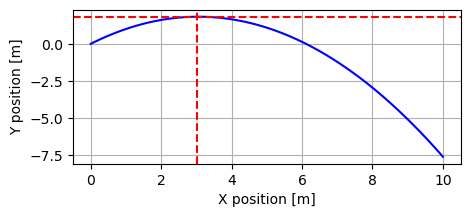

In [27]:
p = Projectile(r0 = [0,0],
               v0 = [5,6],
               g = 9.81,
               t_span = np.linspace(0,2,100)
              )

plt.figure(figsize=(5,2))
plt.plot(p.x, p.y, 'blue')
plt.axhline(p.get_peak_y(), color='r', ls='--')
plt.axvline(p.get_peak_x(), color='r', ls='--')
plt.xlabel('X position [m]')
plt.ylabel('Y position [m]')
plt.grid()
plt.show()

Now that we have a generic understandign of object oriented programming in python, we are going to step away from a physics perspectice and now approahc things from an economics perspective. We will code up a light review from QUANT ECON and then code up a couple models from the more advanced levels of quant econ. Particularly we want to do the market programming and build up the __Solow model__. Building up the solow model is imperative towards understanding how our future research is going to work.

The First example we will go through is building a __Consumer__ class. In our initialized step, we want to give a consumer a certain amount of preexisting wealth. The we define an earn function where the consumer add wealth through y number of dollars and a spend function where consumption is given by spending x dollars. This class is rather simple so we need not spend too much time on it.

In [30]:
class Consumer(): # DO NOT FORGET IN THE FIRST INSTANCE OF THE CLASS, YOU ARE NOT INHERITING ANYTHING AND CANNOT PUT SELF
    def __init__(self, w):
        self.wealth = w

    def earn(self, y):
        self.wealth += y

    def spend(self, x):
        new_wealth = self.wealth - x
        if new_wealth < 0:
            print('Insufficient Funds')
        else:
            self.wealth = new_wealth

c1 = Consumer(10)
c1.spend(5)
c1.wealth
c1.spend(1000)
        

Insufficient Funds


Now we begin the real bulk of this cheatsheet and the most important starting block of our research. Building an initial Solow model on which we can study our initial assumptions and generically test out root solving and other numerical methods on prior to adding our own spin on to things. Notice in this we have a capital accumulation formula given by $$ k_{t+1} = \frac{szk^{\alpha} + (1-\delta)k_{t}}{1+n} $$
In this model, we are going to have an h method which utilizes the right side of the equation and an update function as k converges, then we will have a simple steaddy state and generate sequence method.

When we build the __h function__, we do a step that visually looks a bit backwards. Essentially what we are doing is listing variables we associated with the self.variable  as we would typically define it inside these class methods but just defining the self.variable as the variable itself. This is done striclty to simplify notation rather then constantly having to relist self.variable but it's important to understand it is doing that in the background.

Now notice in __update__ that we are updating our values of k using the h function after it computes our k, this just allows us to continous update k for each new state.
With __Steady Statte__, we do the analytical stuff in the background and just wrote down what our steady state would be.

Now for the __generate sequence__ method. Here we want to use an empty path that we store in the __path__ variable. We then go through the list for our variable t which shows us the amount of steps in our time series, of which we append k into the list. After appending k into the list, we run the __update__ method which will run the right side of our equation to move on to the next step. This cycle continues till our point in the time series has ended.

$$((s*z) / (n + \delta))^{(1/1-\alpha)}$$

In [58]:
class Solow():
    def __init__(self, 
                 n=0.05, # population growth rate
                 s=0.25, # savings rate
                 delta=0.1, # depreciation rate 
                 alpha=0.3, # share of labor
                 z=2.0, # productivity
                 k=1.0): # current capital stock
        self.n, self.s, self.delta, self.alpha, self.z = n, s, delta, alpha, z
        self.k = k

    def h(self):
        n, s, delta, alpha, z, = self.n, self.s, self.delta, self.alpha, self.z
        return (s*z*(self.k**alpha) + (1-delta)*self.k) / (1+n)
        
    def update(self):    
        self.k = self.h()

    def steady_state(self):
        n, s, delta, alpha, z, k = self.n, self.s, self.delta, self.alpha, self.z, self.k
        return ((s*z) / (n + delta))**(1/(1-alpha))

    def generate_sequence(self, t):
        "Generate and return a time series of length t"
        path = []
        for i in range(t):
            path.append(self.k)
            self.update()
        return path

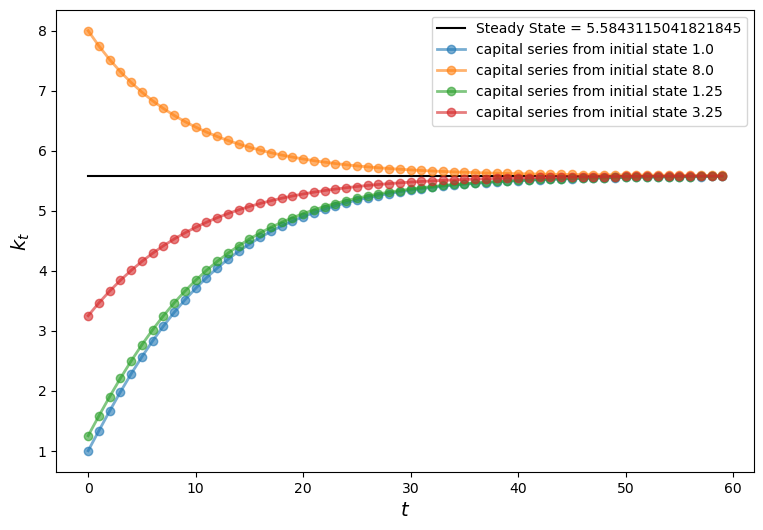

In [72]:
s1 = Solow()
s2 = Solow(k=8.0)
s3 = Solow(k=1.25)
s4 = Solow(k = 3.25)

T = 60
fig, ax = plt.subplots(figsize=(9, 6))

# Plot the common steady state value of capital
ax.plot([s1.steady_state()]*T, 'k-', label= f'Steady State = {s1.steady_state()}')

# Plot time series for each economy
for s in s1, s2, s3, s4:
    lb = f'capital series from initial state {s.k}'
    ax.plot(s.generate_sequence(T), 'o-', lw=2, alpha=0.6, label=lb)

ax.set_xlabel('$t$', fontsize=14)
ax.set_ylabel('$k_t$', fontsize=14)
ax.legend()
plt.show()

What I want to do now is begin the first attemp at building up a class that has all the defined function in our solow model, given some certain constraints and such I will try and build out the functions using the previous values and see if I can come up with given our problem. This will serve as the base template for how we will aproach our model, but for now, we will use this below to build our classes. 

The following will describe the overlapping generations model and we will do a more serious treatment of the model as we go on.
Next we will use newtons method for solving models. 

In [1]:
import numpy as np
from scipy import optimize
from collections import namedtuple
import matplotlib.pyplot as plt

def capital_demand(R, Alpha):
    return (Alpha/R)**(1/(1-Alpha))

def capital_supply(R, Beta, w):
    R = np.ones_like(R)
    return R*(Beta / (1 + Beta)) * w

def equillibrium_R_log_utility(Alpha, w, Beta):
    R = Alpha*((w*Beta)/(1+Beta))**(Alpha-1)
    return R

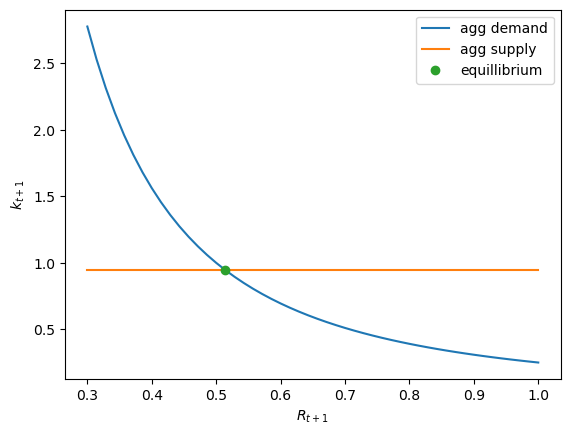

In [8]:
R_vals = np.linspace(0.3, 1, 50)
alpha, beta = 0.5, 0.9
w = 2.0


fig, ax = plt.subplots()
ax.plot(R_vals, capital_demand(R_vals, alpha), label = 'agg demand')

ax.plot(R_vals, capital_supply(R_vals, beta, w), label = 'agg supply')

R_e = equillibrium_R_log_utility(alpha, w, beta)
k_e = (beta / (1 + beta)) * w


ax.plot(R_e, k_e, 'o', label = 'equillibrium')
ax.set_xlabel("$R_{t+1}$")
ax.set_ylabel("$k_{t+1}$")
ax.legend()
plt.show()



You may notice in our construction of capital supply and demand that the savings of capital is also our future capital, which means that the capital we save in period t is the supply of capital in the future thereby $$k_{s} = k_{t+1}$$ We can then create a k_update function like in our solow model for iterating through k.

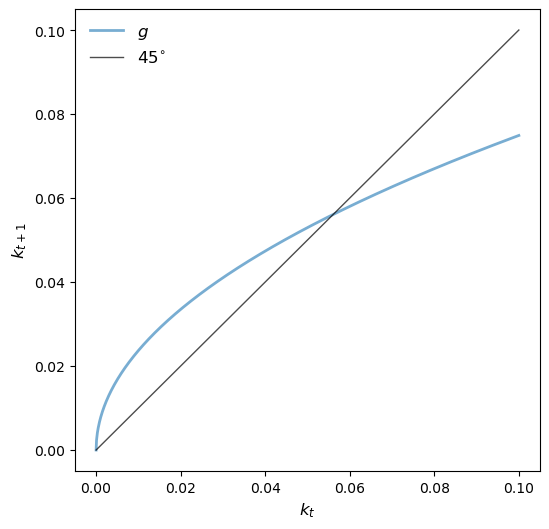

In [14]:
def k_update(beta, alpha, k):
    return (beta * (1 - alpha)*k**alpha) / (1+beta)

α, β = 0.5, 0.9
kmin, kmax = 0, 0.1
n = 1000
k_grid = np.linspace(kmin, kmax, n)
k_grid_next = k_update(beta, alpha, k_grid)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(k_grid, k_grid_next,  lw=2, alpha=0.6, label='$g$')
ax.plot(k_grid, k_grid, 'k-', lw=1, alpha=0.7, label=r'$45^{\circ}$')


ax.legend(loc='upper left', frameon=False, fontsize=12)
ax.set_xlabel('$k_t$', fontsize=12)
ax.set_ylabel('$k_{t+1}$', fontsize=12)

plt.show()

Given this, we understand the existence of a particular steady state for k star that we can solve for analytically. This solution would be $$k_{ss} =\frac{\beta*(1-\alpha)}{1+\beta} ^ \frac{1}{1-\alpha}$$ We also can confirm a steady state fro our interest rates of $$R_{ss} = \frac{\alpha}{1-\alpha} \frac{1+\beta}{\beta}$$

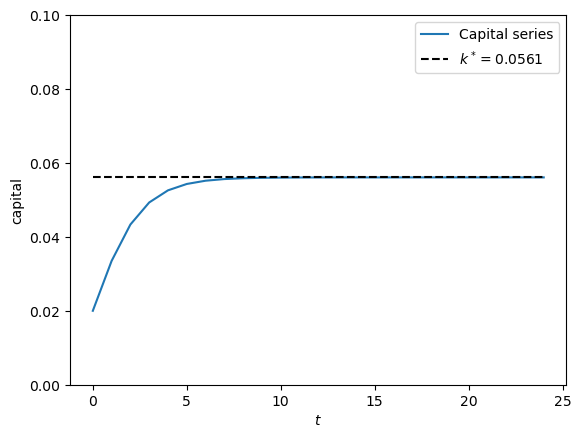

In [17]:
k_star = ((β * (1 - α))/(1 + β))**(1/(1-α))
R_star = (α/(1 - α)) * ((1 + β) / β)

ts_length =  25
k_series = np.empty(ts_length)
k_series[0] = 0.02 # This reflects our initial starting capital
for t in range(ts_length-1):
    k_series[t+1] = k_update(beta, alpha, k_series[t])

fig, ax = plt.subplots()
ax.plot(k_series, label = 'Capital series')
ax.plot(range(ts_length), np.full(ts_length, k_star), 'k--', label=fr'$k^* = {k_star:.4f}$')
ax.set_ylim(0, 0.1)
ax.set_ylabel("capital")
ax.set_xlabel("$t$")
ax.legend()
plt.show()

R_series = α * k_series**(α - 1)

fig, ax = plt.subplots()
ax.plot(R_series, label="gross interest rate")
ax.plot(range(ts_length), np.full(ts_length, R_star), 'k--', label="$R^*$")
ax.set_ylim(0, 4)
ax.set_ylabel("gross interest rate")
ax.set_xlabel("$t$")
ax.legend()
plt.show()

So far, we have approached this thinking of utility as log consumption, but this is not that realistic. A better model of understanding consumption given some steady risk is with a CRRA utility function where $$ u(c) = \frac{c^{1-\gamma}-1}{1-\gamma}$$ This is a more popular choice given it's ability to adjust intertemporal substitution of consumption based on adjustements in interest rates.

Plugging in our CRRA utility function into our maximization will give us our brand new Euler equation:

$$ c_{t}^{-\gamma} = \beta R_{t+1}^{1-\gamma} (w_{t}-c_{t})^{-\gamma} $$ 

We will then solve for savings in order to get our capital supply formula. Solving for this yields:

$$s_{t} = w_{t}*(1+\beta^{\frac{-1}{\gamma}} R_{t+1}^{\frac{\gamma-1}{\gamma}})^{-1} $$

Now recall our origianl demand of

$$\frac{\alpha}{R_{t+1}}^\frac{1}{1-\alpha}$$

When we set these two equivalent to each other we get a equation that would be impossible to solve analytically, that is 

$$ \frac{\alpha}{R_{t+1}}^\frac{1}{1-\alpha} = w_{t}*(1+\beta^{\frac{-1}{\gamma}} R_{t+1}^{\frac{\gamma-1}{\gamma}})^{-1}  $$
additioanlly, we have a sequential equation that would be impossible to solve analytically, we will work on these problems underneath our current exploration of the CRRA utility function



In [27]:
def crra(c, gamma):
    return (c**(1-gamma) - 1) / (1-gamma)
    
Model = namedtuple('Model', ['α',        # Cobb-Douglas parameter
                             'β',        # discount factor
                             'γ']        # parameter in CRRA utility
                   )

def create_olg_model(α=0.4, β=0.9, γ=0.5):
    return Model(α=α, β=β, γ=γ)


def capital_demand(R, model):
    return (model.α/R)**(1/(1-model.α)) 

def savings_crra(w, R, model):
    α, β, γ = model
    return w / (1 + β**(-1/γ) * R**((γ-1)/γ)) 

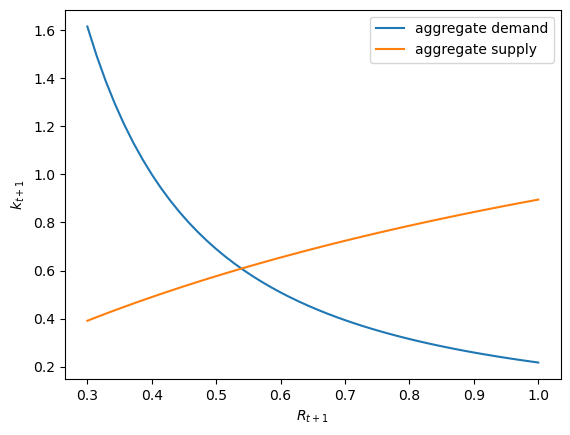

In [28]:
model = create_olg_model()
w = 2.0

fig, ax = plt.subplots()

ax.plot(R_vals, capital_demand(R_vals, model), 
        label="aggregate demand")
ax.plot(R_vals, savings_crra(w, R_vals, model), 
        label="aggregate supply")

ax.set_xlabel("$R_{t+1}$")
ax.set_ylabel("$k_{t+1}$")
ax.legend()
plt.show()

In the following bit of code, we are working to solve the following sequential problem numerically:

$$ k_{t+1} = k_{t}^{\alpha}(1-\alpha)(1+\beta^{\frac{-1}{\gamma}} R_{t+1}^{\frac{\gamma-1}{\gamma}})^{-1} $$


Before we attempt to solve this numerically, we will go through how to solve for these problems using Newton's method.

In [30]:
import matplotlib.pyplot as plt
from typing import NamedTuple
from scipy.optimize import root
import jax.numpy as jnp
import jax


jax.config.update("jax_enable_x64", True)

To properly explain how we approach this method, we will show analytically how to approach building our original solow model through the use of named tuples, this allows us to have relatively clean code as we move forward. We define our iterating function $k_{t+1}$ as g(k) and an exacted fixed point which is our analytical solution.

In [45]:
class SolowParameters(NamedTuple):
    A: float
    s: float
    α: float
    δ: float

def create_SolowParams(A=2.0, s=0.3, α=0.3, δ=0.4):
    return SolowParameters(A=A, s=s, α=α, δ=δ)

def g(k, params):
    A, s, α, δ = params
    return A * s * k**α + (1 - δ) * k


def exact_fixed_point(params):
    A, s, α, δ = params
    return ((s * A) / δ) ** (1 / (1 - α))

In [32]:
def plot_45(params, ax, fontsize=14):

    k_min, k_max = 0.0, 3.0
    k_grid = jnp.linspace(k_min, k_max, 1200)

    # Plot the functions
    lb = r"$g(k) = sAk^{\alpha} + (1 - \delta)k$"
    ax.plot(k_grid, g(k_grid, params), lw=2, alpha=0.6, label=lb)
    ax.plot(k_grid, k_grid, "k--", lw=1, alpha=0.7, label="45")

    # Show and annotate the fixed point
    kstar = exact_fixed_point(params)
    fps = (kstar,)
    ax.plot(fps, fps, "go", ms=10, alpha=0.6)
    ax.annotate(
        r"$k^* = (sA / \delta)^{\frac{1}{1-\alpha}}$",
        xy=(kstar, kstar),
        xycoords="data",
        xytext=(20, -20),
        textcoords="offset points",
        fontsize=fontsize,
    )

    ax.legend(loc="upper left", frameon=False, fontsize=fontsize)

    ax.set_yticks((0, 1, 2, 3))
    ax.set_yticklabels((0.0, 1.0, 2.0, 3.0), fontsize=fontsize)
    ax.set_ylim(0, 3)
    ax.set_xlabel("$k_t$", fontsize=fontsize)
    ax.set_ylabel("$k_{t+1}$", fontsize=fontsize)

SolowParameters(A=2.0, s=0.3, α=0.3, δ=0.4)


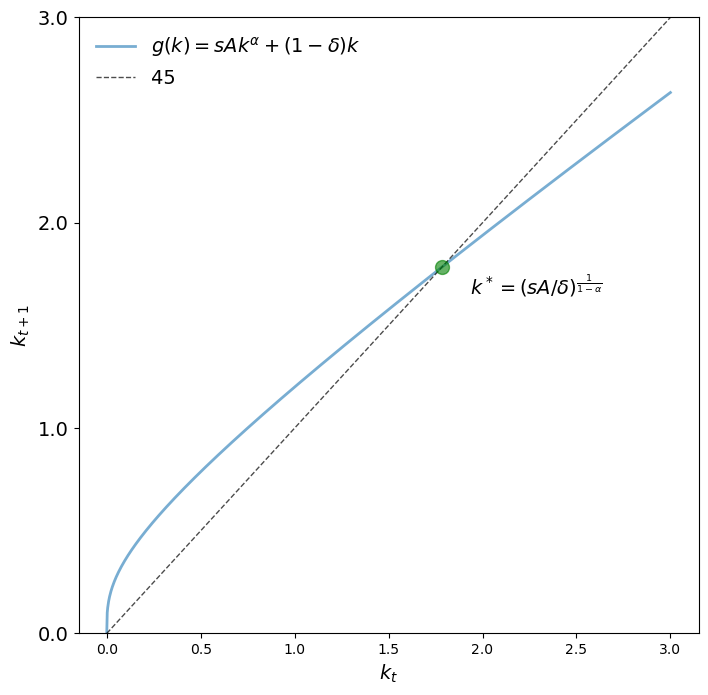

In [34]:
params = create_SolowParams()
print(params)
fig, ax = plt.subplots(figsize=(8, 8))
plot_45(params, ax)
plt.show()


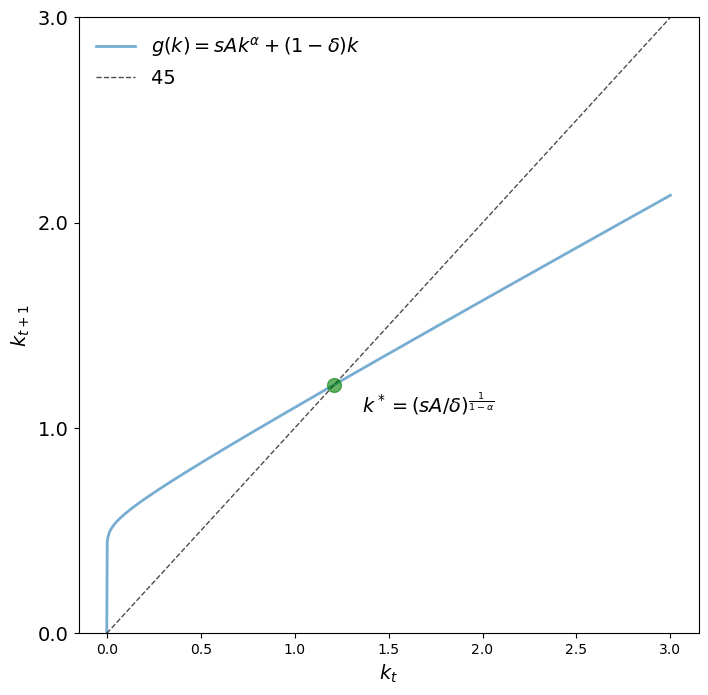

In [43]:
params = create_SolowParams(α=0.05, δ=0.5)
fig, ax = plt.subplots(figsize=(8, 8))
plot_45(params, ax)
plt.show()

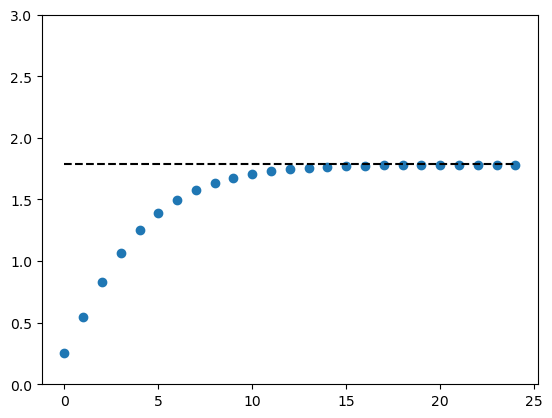

In [52]:
def compute_iterates(k0, f, params, n=25):
    k = k0
    k_iterates = []
    for t in range(n):
        k_iterates.append(k)
        k = f(k, params)
    return k_iterates

params = create_SolowParams()
k0 = 0.25
kseries = compute_iterates(k0, g, params)
k_star = exact_fixed_point(params)

fig, ax = plt.subplots()
ax.plot(k_series, "o")
ax.plot([k_star] * len(k_series), "k--")
ax.set_ylim(0, 3)
plt.show()

In [53]:
k_series = compute_iterates(k_0, g, params, n=10_000)
k_star_approx = k_series[-1]
k_star_approx

1.7846741842265788

The principle of Newton's method works as follows. We use the first order taylor approximation formula, that is

$$g(x) = g(x_{0}) + g^{'}(x - x_{0}) $$ 

For which we solve for the next iterable step as 

$$x_{1} = \frac{g(x_{0})-g^{'}(x_{0})x_{0}}{1-g^{'}(x_{0})}$$

Which further generalizes to

$$x_{t+1} = \frac{g(x_{t})-g^{'}(x_{t})x_{t}}{1-g^{'}(x_{t})}$$

In our application not we are solving for $x_{t} = k_{t}$ and thereby we should treat this our $g^{'}$ as our law of motion of capital or

$$ g^{'} = \alpha s A k^{\alpha-1} +  (1-\delta) $$

In the following step, we will define some functions that equate our previous equation and our iterating equation



In [62]:
def dG(k, params):
    A, s, α, δ = params
    return α*s*A*k**(α-1) + (1-δ)

def q(k, params):
    return (g(k, params) - dG(k,params)*k) / (1-dG(k,params))
    

In [67]:
def plot_trajectories(
    params,
    k0_a=0.8,  # first initial condition
    k0_b=3.1,  # second initial condition
    n=20,      # length of time series
    fs=14,     # fontsize
):

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    ax1, ax2 = axes

    ks1 = compute_iterates(k0_a, g, params, n)
    ax1.plot(ks1, "-o", label="successive approximation")

    ks2 = compute_iterates(k0_b, g, params, n)
    ax2.plot(ks2, "-o", label="successive approximation")

    ks3 = compute_iterates(k0_a, q, params, n)
    ax1.plot(ks3, "-o", label="newton steps")

    ks4 = compute_iterates(k0_b, q, params, n)
    ax2.plot(ks4, "-o", label="newton steps")

    for ax in axes:
        ax.plot(k_star * jnp.ones(n), "k--")
        ax.legend(fontsize=fs, frameon=False)
        ax.set_ylim(0.6, 3.2)
        ax.set_yticks((k_star,))
        ax.set_yticklabels(("$k^*$",), fontsize=fs)
        ax.set_xticks(jnp.linspace(0, 19, 20))

    plt.show()

Breaking down our following code, the newton steps are defined by our q which is what is centering on our inevitable k*, and our blue line is the continous approximations of the successive approximations

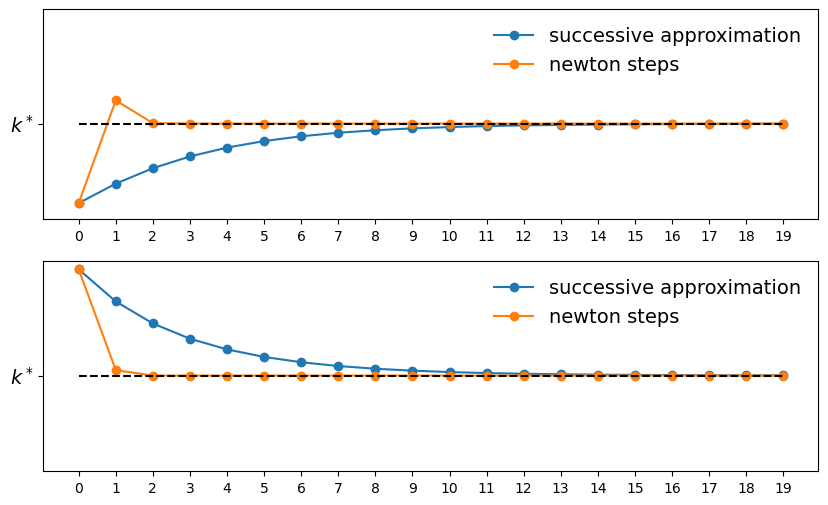

In [68]:
params = create_SolowParams()
plot_trajectories(params)

Before we continue on with any future treatment of Newtons method, we should give a brief introduction to jax and working with vectorized programming. We will be using this as a substitute for the vectorized programming w would be used to in numpy. It's important that you would treat things you do in Jax as you would in Numpy.

We will skip through most the generic vectorized programming introduction as a formality. But you should note it is exactly like np.array but with jnp.array instead in all places. We will list some examples below. 


In [1]:
import jax 
import jax.numpy as jnp

In [2]:
A = jnp.ones((2,2))
B = jnp.identity(2)
A @ B

Array([[1., 1.],
       [1., 1.]], dtype=float32)

In [4]:
from jax.numpy import linalg
linalg.inv(B)

Array([[1., 0.],
       [0., 1.]], dtype=float32)

The most crucial difference between jax and numpy is that arrays are completely immutable. Therefor doing an operation like $a[0] = 1$ will fail when the code is ran. In the following example, we have a scenario that showed how we would approach an adjustement. We can also used the $.at[].set()$ function as a way to adjust indexes. Note that doing this would adjust the identitifier aka, this is a completely new array and variable stored

In [7]:
a = jnp.array((2, 1))
a_new = a.sort()
a, a_new


# Create a sample array
x = jnp.zeros(5)

# Update a single index (e.g., index 2 to value 9.0)
x_new = x.at[2:4].set(9.0)

print(x_new)  # [0. 0. 9. 0. 0.]


[0. 0. 9. 9. 0.]


A crucial thing to note is that you should NOT UNDER ANY CIRCUMSTANCE try to write impure functions by defining global variables outside of a specific class or function definition, this is an important step in working to an approach within functional programming.

Now for the real bulk before we work through newton's method: understanding gradients. Our gradient vector will be a vector made of the partial derivative with respoect to our variable (as you would see typically in something like multivariable calculus)
For a quick example: think of the function $$ f(x) = x^{2} + y^{2} $$. Now for our gradient $\nabla f$: $$\nabla f = [2x, 2y] $$ or more abstractly:
$$\nabla f = [\frac{\partial{f}}{\partial{x}}, \frac{\partial{f}}{\partial{y}}] $$ 

For the following, we will only be working with our single variable function: $$f(x) = \frac{x^{2}}{2}$$. We will then build a gradient function and try and plot for the fixed points of the functions.


In [15]:
def f(x):
    return (x**2)/2

In [17]:
f_prime = jax.grad(f)
f_prime(10.0)
print(f_prime(10.0))

10.0


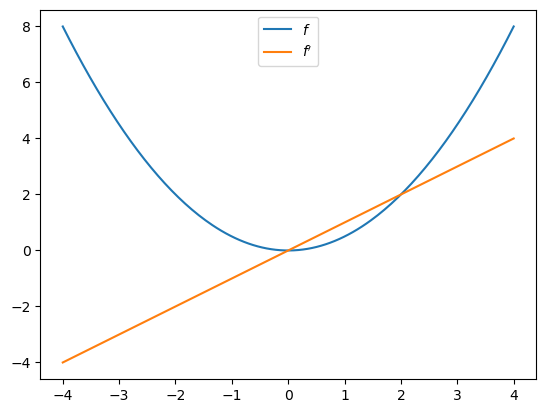

In [19]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots()
x_grid = jnp.linspace(-4,4,200)
ax.plot(x_grid, f(x_grid), label='$f$')
ax.plot(x_grid, [f_prime(x) for x in x_grid], label="$f'$") # this is actually a super cool cheatcode for making arrays of values without the whole for function
ax.legend(loc='upper center')
plt.show()

In [24]:
import numpy as np

@jax.jit

def f(x, y):
    return jnp.cos(x**2 + y**2) / (1 + x**2 + y**2)

n = 6000
x = jnp.linspace(-2, 2, n)
y = x
x_mesh, y_mesh = jnp.meshgrid(x, y)
z_mesh = f(x_mesh, y_mesh).block_until_ready()




The big issue with the code above is a problem of memory usage, which is a ton in this case even for such a small function and amount of iterations, therefore the below code will demosntrate the vectorized version. Using the jax.vmap function, we can remove the need for any of the previous for loops we used to run through our functions

In [28]:
f_vec_y = jax.vmap(f, in_axes=(None, 0))  
f_vec = jax.vmap(f_vec_y, in_axes=(0, None))


z_vmap = f_vec(x, y).block_until_ready()
jnp.allclose(z_vmap, z_mesh)

Array(True, dtype=bool)

Now we will do a treatment breaking down Newton's method using Jax. Note that newton's method. Note this is a method for solving for roots of funtctions when analytically their roots are tricky to solve (as in physically impossible).

Let $f$ be a function from $\mathbb{R}$ to itself. The root of our function for $f(x)$ is a point $x$ such that $f(x)=0$.
We will write out newtons method as:

$$q(x) = x - \frac{f(x)}{f'(x)} $$



In [33]:
import jax
import jax.numpy as jnp
from scipy.optimize import root
import matplotlib.pyplot as plt

def newton_method(f, x_0, tol=1e-5):
    f_prime = jax.grad(f)
    def q(x):
        return x - f(x) / f_prime(x)

    error = tol + 1
    x = x_0

    while error > tol:
        y = q(x)
        error = abs(x-y)
        x=y
        print(x)

    return x


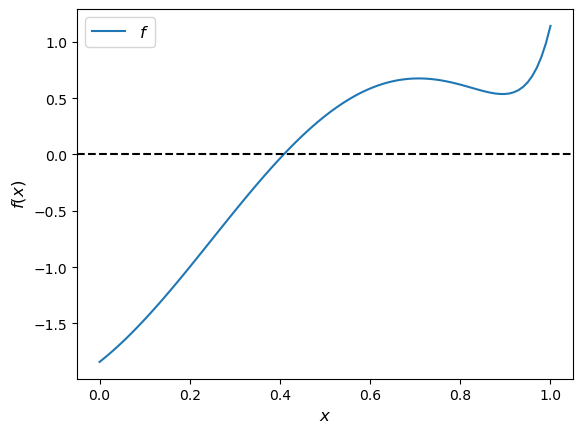

In [30]:
f = lambda x: jnp.sin(4 * (x - 1/4)) + x + x**20 - 1
x = jnp.linspace(0,1,100)

fig, ax = plt.subplots()
ax.plot(x, f(x), label='$f$')
ax.axhline(ls='--', c='k')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.legend(fontsize=12)
plt.show()

In [34]:
newton_method(f, 0.2)

0.4029706
0.40826276
0.40829352
0.40829352


Array(0.40829352, dtype=float32, weak_type=True)

An example of how we would approach this will revolve around a market equillibrium method, given that we will write out some vectorized supply and demand functions that we will solve for using a multivariable newton's method. 

For our supply function:
$$q^{s}(p) = b\sqrt{p} $$

Our demand function:
$$q^{d}(p) = e^{-Ap}+c $$


We will use an excess demand function of the following to find our equillibrium point:
$$e(p) = e^{-Ap}+c - b\sqrt{p} $$
of which will equal 0 at our equillbrium point.

Note then that, our new equillbrium formula works out as 
$$p_{n+1} = p_{n} - J_{e}(p_{n})^{-1}e(p_{n}) $$

In [35]:
def e(p, A, b, c):
    return jnp.exp(- A @ p) + c - b * jnp.sqrt(p)

In [36]:
def newton(f, x_0, tol=1e-5, max_iter=15):
    """
    A multivariate Newton root-finding routine.

    """
    x = x_0
    f_jac = jax.jacobian(f)
    @jax.jit
    def q(x):
        " Updates the current guess. "
        return x - jnp.linalg.solve(f_jac(x), f(x))
    error = tol + 1
    n = 0
    while error > tol:
        n += 1
        if(n > max_iter):
            raise Exception('Max iteration reached without convergence')
        y = q(x)
        error = jnp.linalg.norm(x - y)
        x = y
        print(f'iteration {n}, error = {error}')
    return x

THe above will remain incompleted for now, until I can get more understand more. I will work below on the following problem concerning a solow model problem solving through jax.

In [44]:
A = jnp.array([[2.0,3.0,3.0],
              [2.0,4.0,2.0],
              [1.0,5.0,1.0]])

s = 0.2
α = 0.5
δ = 0.8

def g(k, A=A, s=s, α=α, δ=δ):
    return s*jnp.dot(A,k**α) + (1-δ)*k

    
initLs = [jnp.ones(3),
          jnp.array([3.0, 5.0, 5.0]),
          jnp.repeat(50.0, 3)]

attempt = 1
for init in initLs:
    print(f'Attempt {attempt}: Starting value is {init} \n')
    %time k = newton(lambda k: g(k) - k, \
                     init).block_until_ready()
    print('-'*64)
    attempt += 1

k = newton(lambda k: g(k, A=A, s=s, α=α, δ=δ) - k, \
                 init).block_until_ready()

Attempt 1: Starting value is [1. 1. 1.] 

iteration 1, error = 50.496315002441406
iteration 2, error = 41.1093864440918
iteration 3, error = 4.29412841796875
iteration 4, error = 0.385429710149765
iteration 5, error = 0.0054382034577429295
iteration 6, error = 1.118282284551242e-06
CPU times: total: 531 ms
Wall time: 254 ms
----------------------------------------------------------------
Attempt 2: Starting value is [3. 5. 5.] 

iteration 1, error = 2.070110559463501
iteration 2, error = 0.12642230093479156
iteration 3, error = 0.0006027309573255479
iteration 4, error = 0.0
CPU times: total: 422 ms
Wall time: 234 ms
----------------------------------------------------------------
Attempt 3: Starting value is [50. 50. 50.] 

iteration 1, error = 73.00942993164062
iteration 2, error = 6.4937896728515625
iteration 3, error = 0.680698037147522
iteration 4, error = 0.016203196719288826
iteration 5, error = 1.0210329492110759e-05
iteration 6, error = 5.331201577973843e-07
CPU times: total: 1